Let us try simulate a simple LTI Singularly Perturbed System. 

\begin{equation}
\dot{x} = z(t)
\end{equation}

\begin{equation}
\varepsilon \dot{z} = -x - 2z + u
\end{equation}

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [11]:
def u(t, alpha):
    return 0.5 * np.sin( alpha *  t)


def system(t, state, epsilon, u):
    x, z = state
    dx = z
    dz = (-x - 2*z + u) / epsilon
    return np.array( [ dx, dz] )

C:\Users\yoonj\AppData\Local\Temp\ipykernel_32884\300015264.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


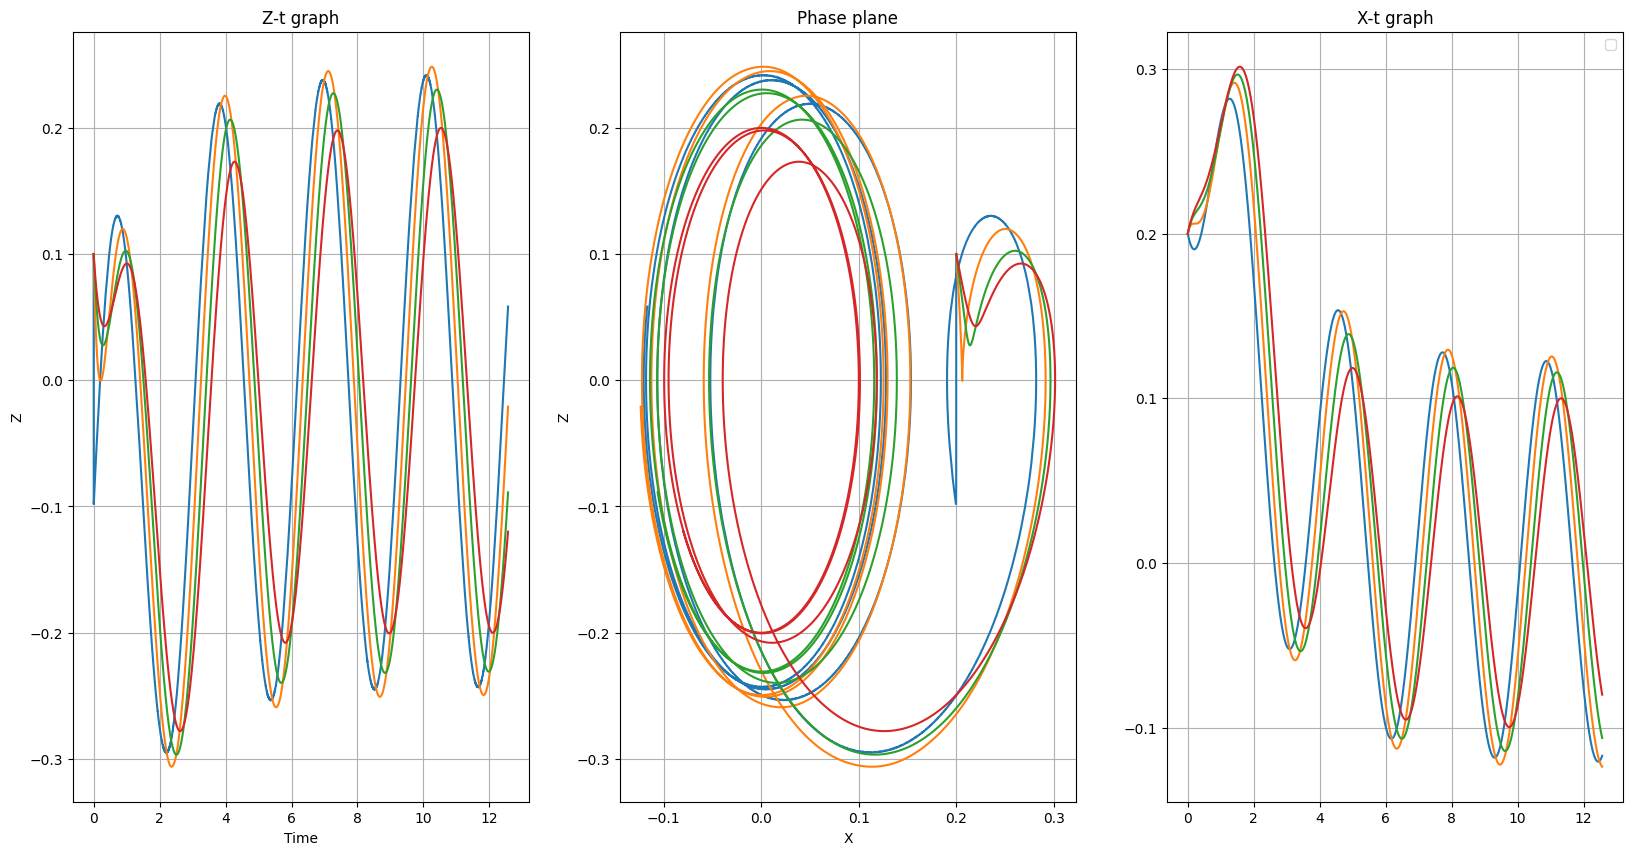

In [14]:
alpha = 2.0
t_span = (0, 4.0* np.pi)
t_eval = np.linspace(t_span[0], t_span[1], 10000)
x0 = [0.2, 0.1]
epsilon = np.linspace(0.001, 1.0, 4)

fig, axs = plt.subplots(1, 3, figsize=(20, 10))
for i in epsilon:
    sol = solve_ivp(
    lambda t, state: system(t, state, i, u(t, alpha)),
    t_span,
    x0,
    t_eval=t_eval)
    
    T_list = sol.t
    x = sol.y[0]
    z = sol.y[1]

    axs[0].plot(T_list, z, label = np.round(i, 3))
    #axs[0].plot(T_list, u(t_eval, alpha))
    
    axs[0].set_title('Z-t graph')
    axs[0].set_xlabel( 'Time' )
    axs[0].set_ylabel( 'Z' )
    axs[0].grid(True)

    axs[1].plot(x, z) #label = np.round(i, 3))
    axs[1].set_title( 'Phase plane')
    axs[1].set_xlabel( 'X')
    axs[1].set_ylabel( 'Z')
    axs[1].grid(True)

    axs[2].plot(T_list, x)
    axs[2].grid(True)
    axs[2].set_title('X-t graph')


#plt.plot(T_list, u(T_list, alpha), label="u(t)")
plt.legend()
plt.show()

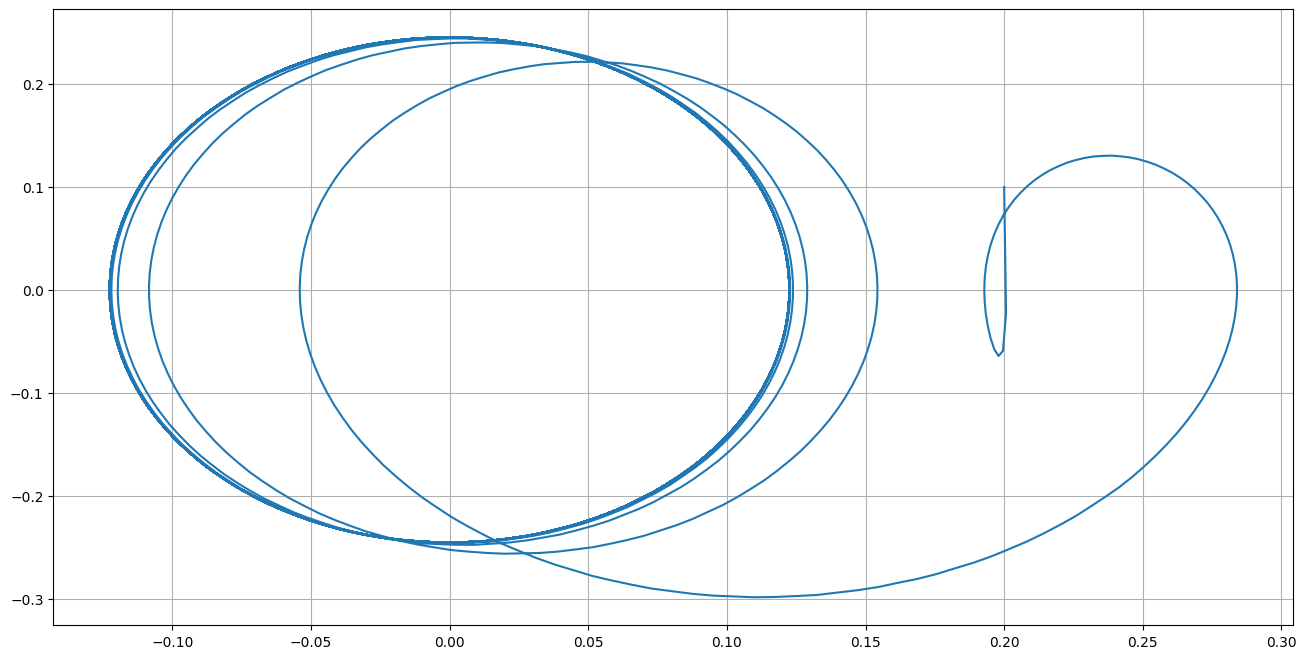

In [13]:
alpha2 = 2.0
t_span = (0, 80.0* np.pi)
t_eval = np.linspace(t_span[0], t_span[1], 10000)
x0 = [0.2, 0.1]
epsilon = 0.05

sol = solve_ivp(
    lambda t, state: system(t, state, epsilon, u(t, alpha)),
    t_span,
    x0,
    t_eval=t_eval)

T_list = sol.t
x = sol.y[0]
z = sol.y[1]

plt.figure( figsize = (16,8) )
plt.plot(x,z)
plt.grid(True)
plt.show()


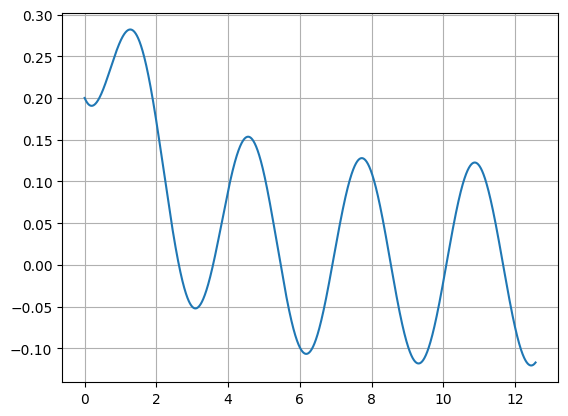

In [28]:
def reduced_model(t, x, u):
    dx = 0.5 * (u - x)
    return dx


red_0 = [0.2]
sol_red = solve_ivp(
    lambda t, state: reduced_model(t, state, u(t, alpha)),
    t_span,
    red_0,
    t_eval=t_eval)

plt.plot(sol_red.t, (sol_red.y).flatten())
plt.grid(True)